# 第 2 步「加噪 forward process」验证 notebook

配套讲解文档：`../../simulation_tutorial.html` 第 2 节。

加噪做的事：把干净数据 `x_0` 按公式逐步泡进高斯噪声，直到变成纯噪声。
$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\qquad \varepsilon\sim\mathcal N(0,I)$$
本 notebook 回答一个核心问题：**加噪之后，数据变成了什么样？**

> 提示：加噪只用到 schedule 系数，**不需要训练好的网络**。所以这里用一个 dummy model 拿到真实
> `GuidedGaussianDiffusion` 的 schedule buffer 即可。请用装好 `requirements.txt` 的内核运行。

In [1]:
# ---- 环境准备 ----
%matplotlib inline
import os, sys, types
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# 自动定位 simulations 目录（含 train.py），无论本 notebook 放在哪层文件夹
_here = os.getcwd()
_cands = [_here, os.path.dirname(_here),
          os.path.join(_here, "simulations"),
          os.path.join(os.path.dirname(_here), "simulations"),
          r"H:\My Drive\Research\DAM\code\GGDMOptim\simulations"]
SIM_DIR = next((c for c in _cands if os.path.exists(os.path.join(c, "train.py"))), _here)
os.chdir(SIM_DIR); sys.path.insert(0, SIM_DIR)

# train.py 顶部 import tensorboard、diffusion.py 顶部 import einops（unet 用）。
# 加噪都用不到，环境若没装就用占位模块绕过 import。
try:
    import tensorboard  # noqa
except ImportError:
    _tb = types.ModuleType("torch.utils.tensorboard")
    class _W:
        def __init__(self,*a,**k): pass
        def add_scalar(self,*a,**k): pass
    _tb.SummaryWriter = _W; sys.modules["torch.utils.tensorboard"] = _tb
try:
    import einops  # noqa
except ImportError:
    _ein = types.ModuleType("einops")
    def _na(*a,**k): raise RuntimeError("einops 占位：加噪用不到")
    _ein.rearrange = _na; _ein.reduce = _na; _ein.repeat = _na
    sys.modules["einops"] = _ein

import numpy as np, torch
import matplotlib.pyplot as plt
from train import LinearLatentData, set_seed
from diffusion import GuidedGaussianDiffusion, extract

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
set_seed(2345)

# 数据生成器（第 1 步）
g = LinearLatentData("data/linear_latent/hyperparameters.npz", d_inner=16, d_outer=64, r_off=9)
M = g.A.T @ g.A   # 64x64 投影矩阵（第 1 步）

# 用 dummy model 拿到真实 schedule buffer（加噪不调用网络）
diff = GuidedGaussianDiffusion(model=torch.nn.Identity(), image_size=64, timesteps=200)
T = diff.num_timesteps

def forward_noise(x0, t, noise=None):
    # 对一批 x0 加噪到时间步 t：x_t = √ᾱ_t·x0 + √(1-ᾱ_t)·ε（与 p_losses 完全一致）
    tt = torch.full((x0.shape[0],), int(t), dtype=torch.long)
    if noise is None:
        noise = torch.randn_like(x0)
    return (extract(diff.sqrt_alphas_cumprod, tt, x0.shape) * x0
            + extract(diff.sqrt_one_minus_alphas_cumprod, tt, x0.shape) * noise)

print("T =", T, "| ᾱ_0 = %.4f | ᾱ_T = %.4f" % (float(diff.alphas_cumprod[0]), float(diff.alphas_cumprod[-1])))

T = 200 | ᾱ_0 = 0.9997 | ᾱ_T = 0.0000


## Part 1 · 噪声 schedule 长什么样

公式 `x_t = √ᾱ_t·x_0 + √(1-ᾱ_t)·ε` 里两个系数随 t 此消彼长：
- `√ᾱ_t`（信号系数）：从 1 → 0，原始数据被越压越小
- `√(1-ᾱ_t)`（噪声系数）：从 0 → 1，噪声越加越多

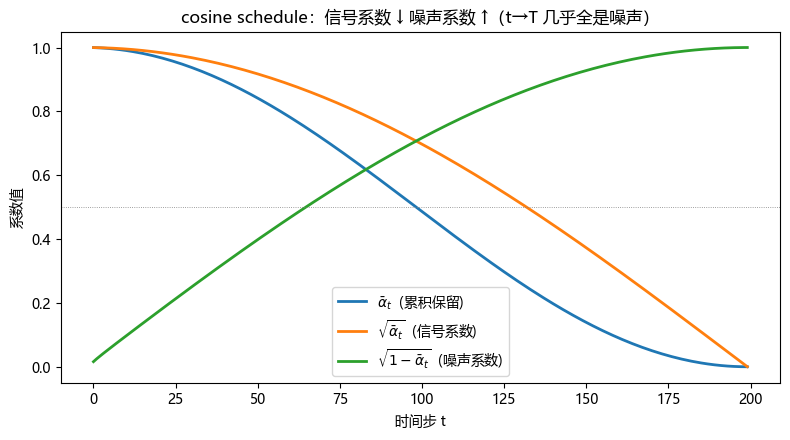

t=  0:  √ᾱ_t=1.000  √(1-ᾱ_t)=0.016
t= 50:  √ᾱ_t=0.917  √(1-ᾱ_t)=0.398
t=100:  √ᾱ_t=0.697  √(1-ᾱ_t)=0.717
t=150:  √ᾱ_t=0.373  √(1-ᾱ_t)=0.928
t=199:  √ᾱ_t=0.000  √(1-ᾱ_t)=1.000


In [2]:
t_axis = np.arange(T)
abar     = diff.alphas_cumprod.numpy()
sig_coef = diff.sqrt_alphas_cumprod.numpy()          # √ᾱ_t
noi_coef = diff.sqrt_one_minus_alphas_cumprod.numpy() # √(1-ᾱ_t)

plt.figure(figsize=(8, 4.5))
plt.plot(t_axis, abar,     label=r"$\bar\alpha_t$  (累积保留)", lw=2)
plt.plot(t_axis, sig_coef, label=r"$\sqrt{\bar\alpha_t}$  (信号系数)", lw=2)
plt.plot(t_axis, noi_coef, label=r"$\sqrt{1-\bar\alpha_t}$  (噪声系数)", lw=2)
plt.axhline(0.5, color="grey", lw=0.6, ls=":")
plt.xlabel("时间步 t"); plt.ylabel("系数值"); plt.legend()
plt.title("cosine schedule：信号系数 ↓ 噪声系数 ↑（t→T 几乎全是噪声）")
plt.tight_layout(); plt.show()

for t in [0, 50, 100, 150, 199]:
    print(f"t={t:3d}:  √ᾱ_t={sig_coef[t]:.3f}  √(1-ᾱ_t)={noi_coef[t]:.3f}")

## Part 2 · 加噪后数据变成什么样？

拿一批真实 `x_0`（落在 16 维子空间上），逐步加噪：
- **off-support ratio**（数据离流形多远）会从 0 一路爬到 √3 ≈ 1.73 —— 也就是从"贴在 16 维流形上"变成"铺满整个 64 维空间、与纯噪声无异"
- `‖x_t‖` 随 t 增大（噪声把范数从 √16 推向 √64 ≈ 8）

**为什么终点是 √3？** `x_0` 只有平行分量；加噪后垂直方向（48 维）全是纯噪声、平行方向（16 维）也被噪声淹没，比值 → √(48/16)=√3。

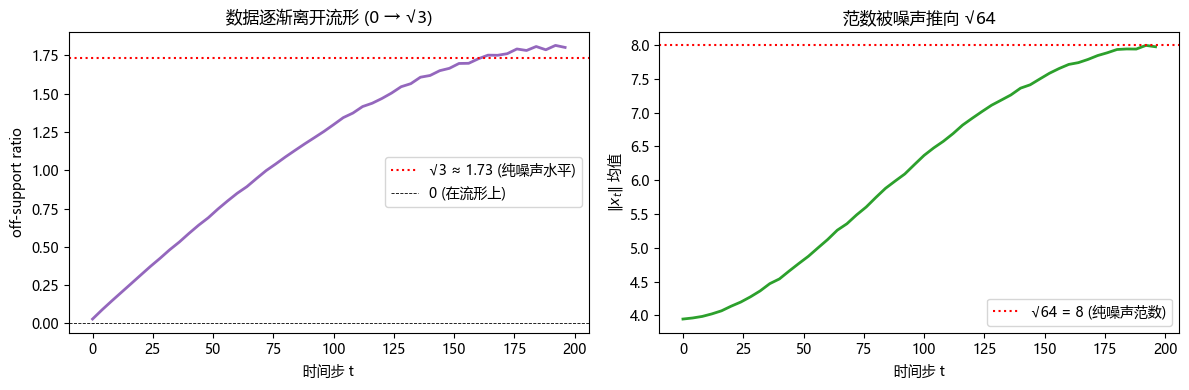

t=0  off-ratio=0.029  | t=T off-ratio=1.802


In [3]:
set_seed(2345)
x0 = torch.from_numpy(g.generate_x(2000)).float()

grid = np.arange(0, T, 4)               # 每 4 步取一个时间点
off_curve, norm_curve = [], []
for t in grid:
    xt = forward_noise(x0, t)
    off_curve.append(g.off_support_ratio(xt.numpy()).mean())
    norm_curve.append(np.linalg.norm(xt.numpy(), axis=1).mean())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(grid, off_curve, lw=2, color="tab:purple")
ax[0].axhline(np.sqrt(3), color="r", ls=":", label="√3 ≈ 1.73 (纯噪声水平)")
ax[0].axhline(0, color="k", lw=0.6, ls="--", label="0 (在流形上)")
ax[0].set_xlabel("时间步 t"); ax[0].set_ylabel("off-support ratio")
ax[0].set_title("数据逐渐离开流形 (0 → √3)"); ax[0].legend()

ax[1].plot(grid, norm_curve, lw=2, color="tab:green")
ax[1].axhline(np.sqrt(64), color="r", ls=":", label="√64 = 8 (纯噪声范数)")
ax[1].set_xlabel("时间步 t"); ax[1].set_ylabel(r"$\|x_t\|$ 均值")
ax[1].set_title("范数被噪声推向 √64"); ax[1].legend()
plt.tight_layout(); plt.show()

print("t=0  off-ratio=%.3f" % off_curve[0], " | t=T off-ratio=%.3f" % off_curve[-1])

### 2D 快照：直观看到点从流形上"扩散"开

沿用第 1 步 Part 5 的两个方向（子空间内 vs 垂直于子空间），在 t=0 / 中间 / t=T 各画一张散点。
t=0 时点全贴在 y=0 线上；t 越大，点在垂直方向（y 轴）扩散得越开 —— 这就是"加噪填满了流形之外的方向"。

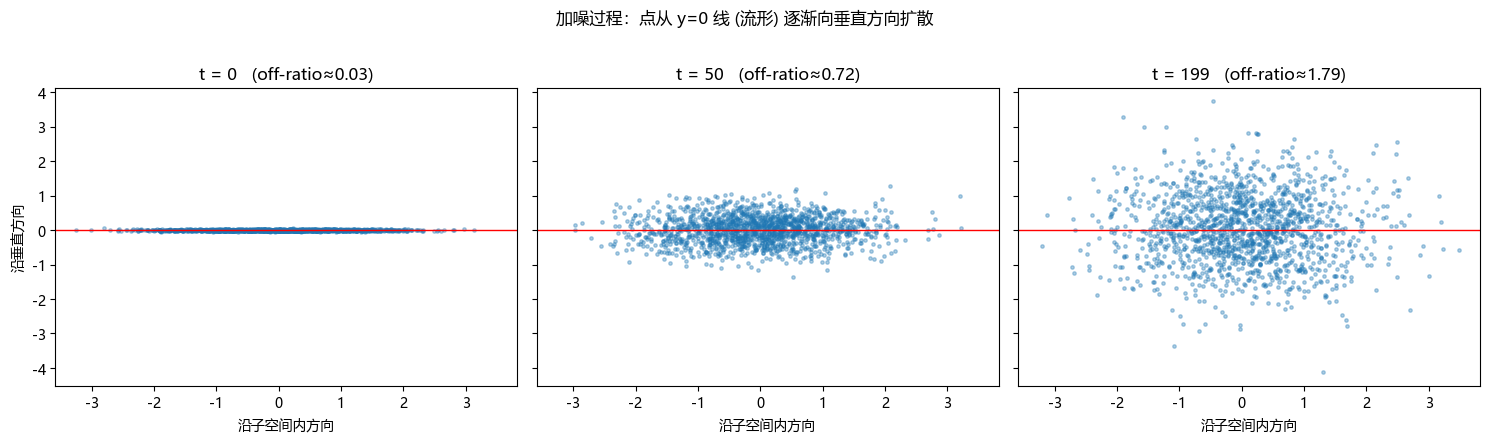

In [4]:
in_dir = g.A[0] / np.linalg.norm(g.A[0])        # 子空间内方向
rv = np.random.randn(64); rv = rv - rv @ M         # 投到正交补
off_dir = rv / np.linalg.norm(rv)                  # 垂直方向

sub = 1500
snaps = [0, T // 4, T - 1]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3), sharex=True, sharey=True)
for k, t in enumerate(snaps):
    xt = forward_noise(x0[:sub], t).numpy()
    c_in, c_off = xt @ in_dir, xt @ off_dir
    ax[k].scatter(c_in, c_off, s=6, alpha=0.35)
    ax[k].axhline(0, color="r", lw=1)
    ax[k].set_title(f"t = {t}   (off-ratio≈{g.off_support_ratio(xt).mean():.2f})")
    ax[k].set_xlabel("沿子空间内方向")
ax[0].set_ylabel("沿垂直方向")
fig.suptitle("加噪过程：点从 y=0 线 (流形) 逐渐向垂直方向扩散", y=1.02)
plt.tight_layout(); plt.show()

### 单个样本的加噪全过程：看实际数值的变化

x 是 64 维向量、没有图像那样的空间结构，所以"看不出具体内容"是正常的。但我们可以：
- 把 64 个分量 reshape 成 **8×8 热图**当"小图"看
- 同时把它当成一条 **64 维 1D 信号**画出来

用**同一个固定的噪声实现** ε（不是每步独立采样），这样能看到 `x_0` 的结构被这团噪声**平滑地、连贯地**淹没：
`x_t = √ᾱ_t·x_0 + √(1-ᾱ_t)·ε`，t 小≈x_0，t 大≈ε。

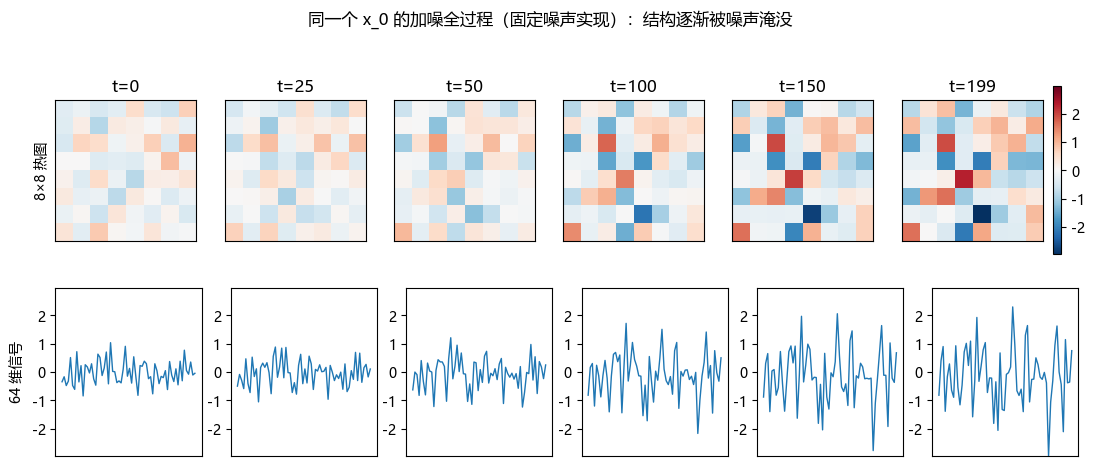

‖x_0‖ = 3.35 (≈√16=4, 数据)   →   ‖x_T‖ = 8.19 (≈√64=8, 噪声)


In [8]:
set_seed(7)
x0_one = torch.from_numpy(g.generate_x(1)).float()   # 取 1 个样本 (1,64)
eps = torch.randn_like(x0_one)                        # 固定一个噪声实现，让过程连贯

ts = [0, 25, 50, 100, 150, 199]
xts = [forward_noise(x0_one, t, noise=eps)[0].numpy() for t in ts]
vlim = np.abs(np.concatenate(xts)).max()              # 统一色标/纵轴

fig, ax = plt.subplots(2, len(ts), figsize=(2.2*len(ts), 4.8))
for k, (t, xt) in enumerate(zip(ts, xts)):
    # 上排：reshape 成 8x8 当"图像"看（统一色标）
    im = ax[0, k].imshow(xt.reshape(8, 8), cmap="RdBu_r", vmin=-vlim, vmax=vlim)
    ax[0, k].set_title(f"t={t}"); ax[0, k].set_xticks([]); ax[0, k].set_yticks([])
    # 下排：把 64 个分量当 1D 信号画（统一纵轴）
    ax[1, k].plot(xt, lw=1, color="tab:blue")
    ax[1, k].set_ylim(-vlim, vlim); ax[1, k].set_xticks([])
ax[0, 0].set_ylabel("8×8 热图"); ax[1, 0].set_ylabel("64 维信号")
fig.colorbar(im, ax=ax[0, :].tolist(), fraction=0.025, pad=0.01)
fig.suptitle("同一个 x_0 的加噪全过程（固定噪声实现）：结构逐渐被噪声淹没", y=1.04)
plt.show()

print("‖x_0‖ = %.2f (≈√16=4, 数据)   →   ‖x_T‖ = %.2f (≈√64=8, 噪声)"
      % (np.linalg.norm(xts[0]), np.linalg.norm(xts[-1])))

## 小结

| 现象 | 结论 |
|---|---|
| `√ᾱ_t` ↓ / `√(1-ᾱ_t)` ↑ | 信号被压小、噪声被加大 |
| off-ratio 随 t | 0 → √3：数据从流形上逐渐铺满全空间 |
| `‖x_t‖` 随 t | √16 → √64：终点是标准高斯噪声 |
| 2D 快照 / 单样本全过程 | 结构从流形上逐渐被噪声淹没 |

**加噪后得到的"data"**：不是一份新数据集，而是一条从「真实数据」到「纯高斯噪声」的连续噪声链 `x_0 → x_1 → … → x_T`。
关键意义 —— 原本数据挤在 16 维子空间上（流形外没定义 score），加噪后填满整个 64 维空间，于是 score 处处可学。

**下一步（第 3 步）**：训练 denoiser，让网络学会从 `x_t` 预测当初加进去的噪声 `ε`，也就是反向擦掉噪声的能力。